In [ ]:
# import all libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# Optional: Display plots inside Jupyter
%matplotlib inline

In [4]:
# Load the datasets.

train_df = pd.read_csv("customer_churn_dataset-training-master.csv")
test_df = pd.read_csv("customer_churn_dataset-testing-master.csv")

In [5]:
train_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [7]:
print("Training data shape:" , train_df.shape)
print("Testing data shape:" , test_df.shape) 

Training data shape: (440833, 12)
Testing data shape: (64374, 12)


In [8]:
# column names of dataset

train_df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='str')

In [9]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


In [10]:
train_df.dtypes

CustomerID           float64
Age                  float64
Gender                   str
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type        str
Contract Length          str
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object

In [11]:
train_df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [12]:
train_df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [13]:
train_df.duplicated().sum()


np.int64(0)

In [17]:
train_df["Churn"].value_counts()

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

In [19]:
# Percentage distribution of the target variable
train_df["Churn"].value_counts(normalize=True) * 100

Churn
1.0    56.71072
0.0    43.28928
Name: proportion, dtype: float64

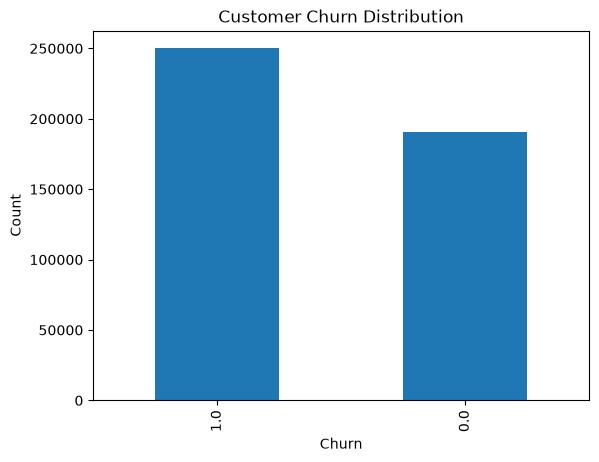

In [18]:
# churn visualization via bar-plot 

train_df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

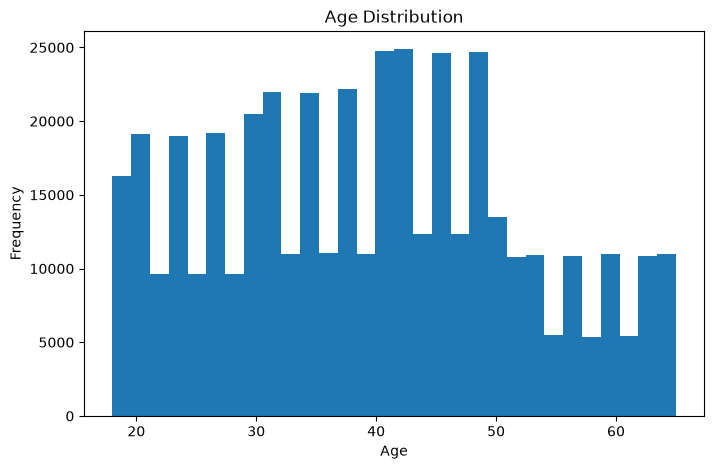

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(train_df["Age"], bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

#higher churn in ages 25-40

In [21]:
# splitting data into training and testing data
# Separate features and target
X_train = train_df.drop("Churn", axis=1)
y_train = train_df["Churn"]

X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

In [ ]:
print("Training Features:", X_train.shape)
print("Training Target:", y_train.shape)

print("Testing Features:", X_test.shape)
print("Testing Target:", y_test.shape)

# 11 features as column "Churn" is excluded

Training Features: (440833, 11)
Training Target: (440833,)
Testing Features: (64374, 11)
Testing Target: (64374,)


In [23]:
X_train.dtypes

CustomerID           float64
Age                  float64
Gender                   str
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type        str
Contract Length          str
Total Spend          float64
Last Interaction     float64
dtype: object

In [24]:
# Encode categorical columns
categorical_columns = [
    "Gender",
    "Subscription Type",
    "Contract Length"
]

X_train = pd.get_dummies(
    X_train,
    columns=categorical_columns,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_columns,
    drop_first=True
)

# decision trees cannot train features having data type string
# we encode those features 